# Fixed Scaled-Release Policy Ablation

This notebook evaluates simple fixed scaled-release policies as an ablation study for the ADMM-MPC ramp-metering controller.

The purpose of this experiment is to test whether the ADMM-MPC improvement can be explained merely by reducing ramp releases, or whether the rolling-horizon ADMM-MPC controller provides additional benefit beyond simple uniform metering.

---

## Motivation

The benchmark policy uses the field-observed PeMS ramp release series. However, ramp arrivals are not directly observed from the PeMS ramp detector data. The detector measures vehicles discharged from the ramp, not the true number of vehicles arriving to the ramp queue.

Therefore, ramp demand is modeled as a multiple of the observed release series:

$$
\text{ramp arrival}_{r,t}
=
m \cdot \text{observed release}_{r,t}
$$

where:

$$
m
$$

is the ramp-arrival multiplier.

The official benchmark and ADMM-MPC experiments use:

$$
m = 1.5
$$

To avoid relying on a single demand assumption, this notebook tests multiple ramp-arrival multipliers:

$$
m \in \{1.0,\ 1.1,\ 1.25,\ 1.5\}
$$

---

## Fixed Scaled-Release Policy

For each ramp and timestep, the fixed policy releases a constant fraction of the observed PeMS release:

$$
u_{r,t}^{\text{fixed}}
=
\alpha \cdot u_{r,t}^{\text{observed}}
$$

where:

$$
\alpha
$$

is the fixed release scale.

This notebook tests:

$$
\alpha \in \{0.7,\ 0.8,\ 0.9,\ 1.0\}
$$

The case:

$$
\alpha = 1.0
$$

corresponds to the observed-release baseline under the selected ramp-arrival multiplier.

The cases:

$$
\alpha < 1.0
$$

represent simple non-optimized ramp metering policies that uniformly reduce ramp releases while preserving the observed time-varying release pattern.

---

## Why This Ablation Is Needed

This ablation checks whether ADMM-MPC is only improving the objective by releasing fewer ramp vehicles.

If a simple fixed release scale performs similarly to ADMM-MPC, then the ADMM-MPC improvement may not come from optimization. If ADMM-MPC performs better than moderate fixed scaled-release policies, then the rolling-horizon controller provides additional benefit beyond uniform metering.

This experiment also checks whether aggressive ramp metering reduces freeway delay by increasing spillback or rejecting more ramp demand.

---

## Compared Policies

The notebook compares:

| Policy | Description |
|---|---|
| Baseline | Observed PeMS ramp release |
| Fixed 0.7x | Releases 70 percent of observed PeMS ramp discharge |
| Fixed 0.8x | Releases 80 percent of observed PeMS ramp discharge |
| Fixed 0.9x | Releases 90 percent of observed PeMS ramp discharge |
| Fixed 1.0x | Same as observed-release baseline |
| ADMM-MPC | Rolling-horizon optimized ramp release policy |

All policies use the same mainline boundary inflow, off-ramp flow series, CTM dynamics, capacity parameters, and ramp storage limits.

---

## Main Findings

Under the official ramp-arrival multiplier:

$$
m = 1.5
$$

the fixed scaled-release policies show that uniformly reducing ramp releases can reduce mainline congestion and improve the normalized objective. However, aggressive fixed reductions achieve this partly by increasing ramp spillback and serving fewer ramp vehicles.

The ADMM-MPC controller improves substantially over the observed-release baseline and moderate fixed scaled-release policies. However, the most restrictive fixed policy has the lowest normalized objective because it releases fewer ramp vehicles and produces the largest spillback.

Therefore, the result should be interpreted as a freeway-ramp tradeoff, not as a universal improvement in all traffic conditions.

---

## Official-Setting Comparison

For the official ramp-arrival multiplier:

$$
m = 1.5
$$

the key comparison is:

| Policy | Total Delay | Normalized Objective | Served Ramp Demand | Spillback Share |
|---|---:|---:|---:|---:|
| Baseline | 88074.3 | 34.000 | 66.7 percent | 28.9 percent |
| Fixed 0.7x | 51657.1 | 18.277 | 46.7 percent | 48.9 percent |
| Fixed 0.8x | 63869.5 | 23.418 | 53.3 percent | 42.2 percent |
| Fixed 0.9x | 75955.4 | 28.617 | 60.0 percent | 35.6 percent |
| ADMM-MPC | 60445.9 | 20.950 | 52.2 percent | 43.3 percent |

This shows that ADMM-MPC performs better than the baseline and moderate fixed-release policies. The most restrictive fixed policy achieves the lowest delay and objective value, but it does so by serving the smallest share of ramp demand and producing the highest spillback.

---

## Demand-Accounting Check

The demand-accounting diagnostic verifies ramp-flow conservation:

$$
\text{initial queue}
+
\text{ramp arrivals}
=
\text{released vehicles}
+
\text{final queue}
+
\text{spilled vehicles}
$$

For all policies, the residual is approximately zero. This confirms that ramp demand is being accounted for correctly.

The downstream mainline exit flow is nearly identical across policies, which means the policies mainly change where vehicles wait:

| Waiting Location | Meaning |
|---|---|
| Mainline | Freeway congestion |
| Ramp queue | Vehicles waiting on ramps |
| Spillback | Vehicles exceeding ramp storage capacity |

Thus, the controller does not increase total corridor discharge. Instead, it redistributes congestion between the freeway and ramps.

---

## Interpretation

The fixed-policy ablation shows that simple uniform ramp metering can improve freeway-side performance, but aggressive metering can also push congestion onto ramps and increase spillback.

ADMM-MPC provides a controlled tradeoff between freeway delay, ramp delay, and capacity penalties. It is not simply copying a fixed release reduction. Its advantage is that it adapts releases over time using rolling-horizon optimization, while still being subject to ramp storage and vehicle-availability constraints.

The main conclusion is:

ADMM-MPC improves over the observed-release baseline and moderate fixed scaled-release policies, but its benefits must be interpreted together with ramp-side impacts such as spillback and served-demand percentage.

---

## Reproducibility Notes

This notebook depends on the benchmark and ADMM-MPC notebooks being run first:

```python
%run Benchmark_calculation.ipynb
%run ADMM_MPC.ipynb

Selected Station Metadata 
Number of selected stations: 15


,station_id,station_name,station_type,freeway,direction,absolute_postmile,length,lanes,latitude,longitude
0,1201419,RED HILL,ML,405,S,8.17,0.269,5,33.686517,-117.866474
1,1201465,BRISTOL 1,FR,405,S,9.31,NaN,2,33.687251,-117.886180
2,1201469,BRISTOL 1,ML,405,S,9.31,0.350,5,33.687251,-117.886180
3,1201460,BRISTOL 1,OR,405,S,9.31,NaN,1,33.687251,-117.886180
4,1201497,FAIRVIEW,ML,405,S,10.05,0.460,5,33.687480,-117.899035
5,1201490,FAIRVIEW,OR,405,S,10.07,NaN,1,33.687494,-117.899383
6,1201525,HARBOR 1,ML,405,S,10.97,0.610,6,33.687942,-117.915002
7,1201517,HARBOR 1,OR,405,S,10.97,NaN,1,33.687942,-117.915002
8,1201554,HARBOR 2,FR,405,S,11.27,NaN,3,33.689212,-117.919950
9,1201558,HARBOR 2,ML,405,S,11.27,0.480,5,33.689212,-117.919950


Midnight / Free-Flow Window Data 
Time window: 2026-01-08 01:00:00 to 2026-01-08 05:00:00
Rows: 720
Unique timestamps: 48
Unique stations: 15

First 20 rows:


,timestamp,station_id,station_type,total_flow,avg_occupancy,avg_speed
0,2026-01-08 01:00:00,1201419,ML,112.0,0.0345,47.3
1,2026-01-08 01:00:00,1201460,OR,0.0,0.0000,NaN
2,2026-01-08 01:00:00,1201465,FR,NaN,NaN,NaN
3,2026-01-08 01:00:00,1201469,ML,112.0,0.0257,61.4
4,2026-01-08 01:00:00,1201490,OR,9.0,0.0200,NaN
5,2026-01-08 01:00:00,1201497,ML,55.0,0.0049,69.8
6,2026-01-08 01:00:00,1201517,OR,3.0,0.0030,NaN
7,2026-01-08 01:00:00,1201525,ML,54.0,0.0097,64.5
8,2026-01-08 01:00:00,1201548,OR,6.0,0.0110,NaN
9,2026-01-08 01:00:00,1201554,FR,10.0,0.0033,NaN



Rows for station 1201419 (RED HILL):


...

Soft-capacity violation summary by cell


,cell,violation_steps,max_doorway_overflow,max_safe_overflow,max_physical_overflow
0,Cell 2,23,8.8,0.000,0.0
1,Cell 4,98,5.1,106.992,0.0
2,Cell 5,83,0.0,138.156,0.0
3,Cell 6,120,8.2,0.000,0.0
4,Cell 7,74,0.0,135.756,0.0


Problem 19: Conservative Off-Ramp Outflow Diagnostic
Total capped off-ramp events: 0
Max requested-minus-actual off-ramp gap: 0.0
PASS: no off-ramp over-drain occurred in the benchmark run.
Loaded official benchmark totals:
mainline_delay = 72848.691296
local_delay = 15225.6536
fairness_penalty = 25.452969
doorway_penalty = 5712.107584
safe_penalty = 1410495.371527
physical_penalty = 0.0
spillback_penalty = 3454.202029
capacity_penalty = 1419661.68114
raw_objective = 1507761.479005

Loaded benchmark denominators:
D_main_base = 72848.691296
D_local_base = 15225.6536
L_fair_base = 25.452969
P_door_base = 5712.107584
P_safe_base = 2820990.743053
P_phys_base = 1.0
P_spill_base = 6908.404057
Mainline IDs: [1201419, 1201469, 1201497, 1201525, 1201558, 1201589, 1201620]
On-ramp IDs: [1201460, 1201490, 1201517, 1201548, 1201580]
Off-ramp IDs: [1201465, 1201554, 1201585]
All selected IDs: [1201419, 1201469, 1201497, 1201525, 1201558, 1201589, 1201620, 1201460, 1201490, 1201517, 1201548, 1201580

,cell,initial_state_x0
0,Cell 1,121.616
1,Cell 2,124.200
2,Cell 3,93.752
3,Cell 4,97.672
4,Cell 5,171.734
5,Cell 6,176.459
6,Cell 7,216.385
7,Cell 8,159.833


 ADMM-MPC x0 source verification
ADMM-MPC mainline_initial_state loaded from shared_benchmark_inputs.pkl:
Cell 1 = 121.615803
Cell 2 = 124.200202
Cell 3 = 93.752384
Cell 4 = 97.672005
Cell 5 = 171.734343
Cell 6 = 176.458936
Cell 7 = 216.384827
Cell 8 = 159.833095

PASS: ADMM-MPC uses benchmark-exported mainline_initial_state.
ADMM-MPC configuration:
num_steps = 120
delta_t = 0.5

ADMM-MPC objective weights:
alpha_main = 30.0
beta_local = 1.0
gamma = 1
lambda_1 = 1.0
lambda_2 = 0.5
lambda_3 = 1.0
lambda_4 = 0.5
Loaded shared benchmark inputs.
D_main_base = 72848.691
D_local_base = 15225.654
P_safe_base = 2820990.743
PASS: %run Benchmark_calculation.ipynb variables match shared_benchmark_inputs.pkl
JSON Cell 18 | type = code
import json

notebook_path = "ADMM_MPC.ipynb"

with open(notebook_path, "r", encoding="utf-8") as f:
    nb = json.load(f)

for cell_id in [18, 20, 23]:
    cell = nb["cells"][cell_id]
    print("=" * 100)
    print(f"JSON Cell {cell_id} | type = {cell['cell_type']}"

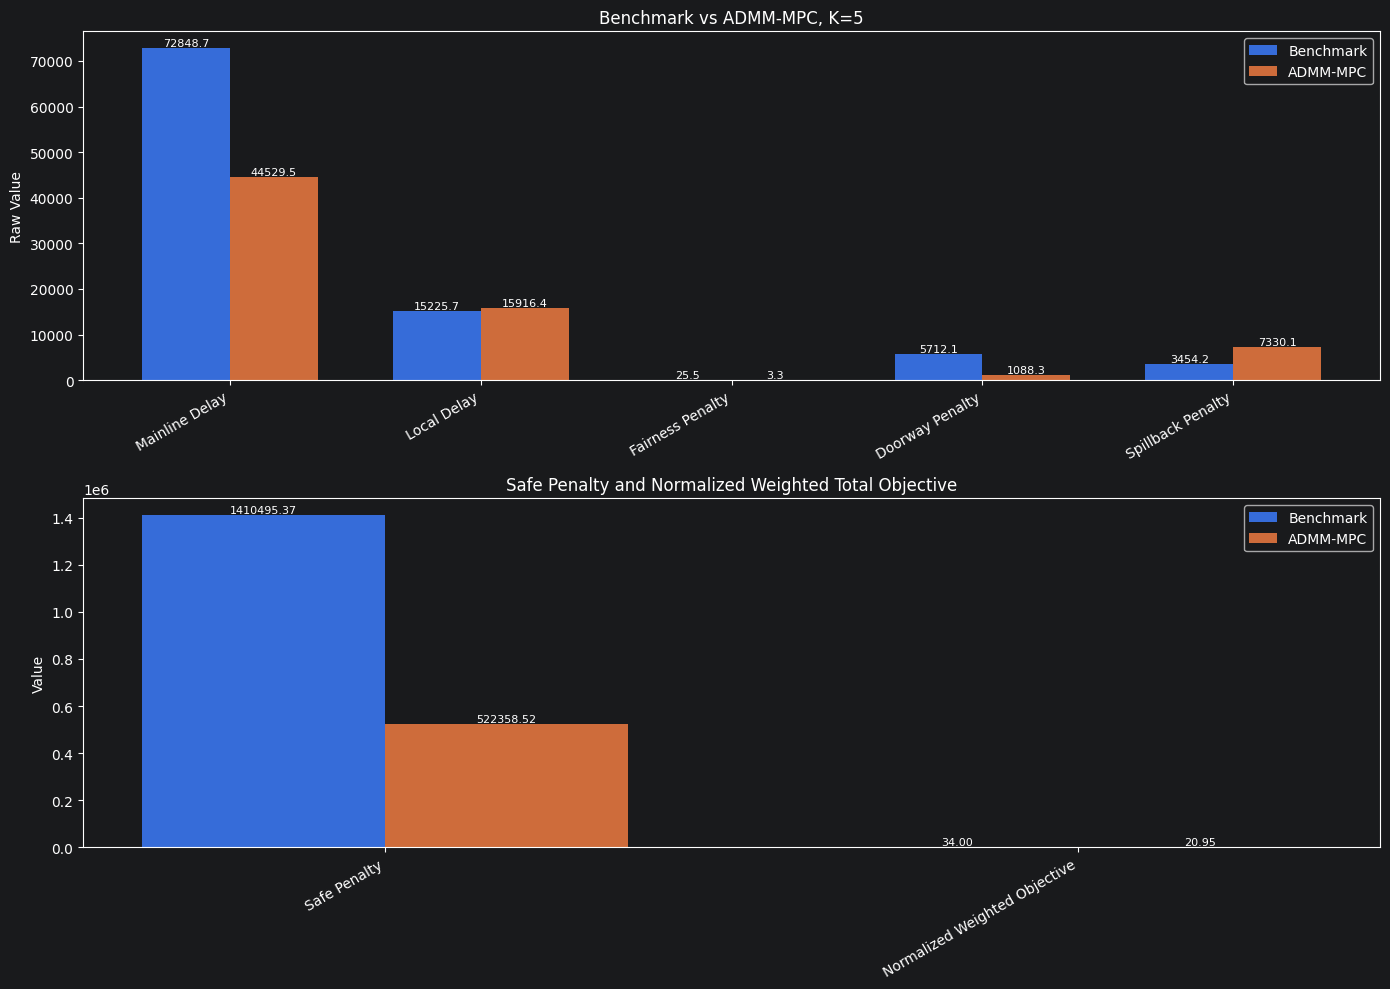

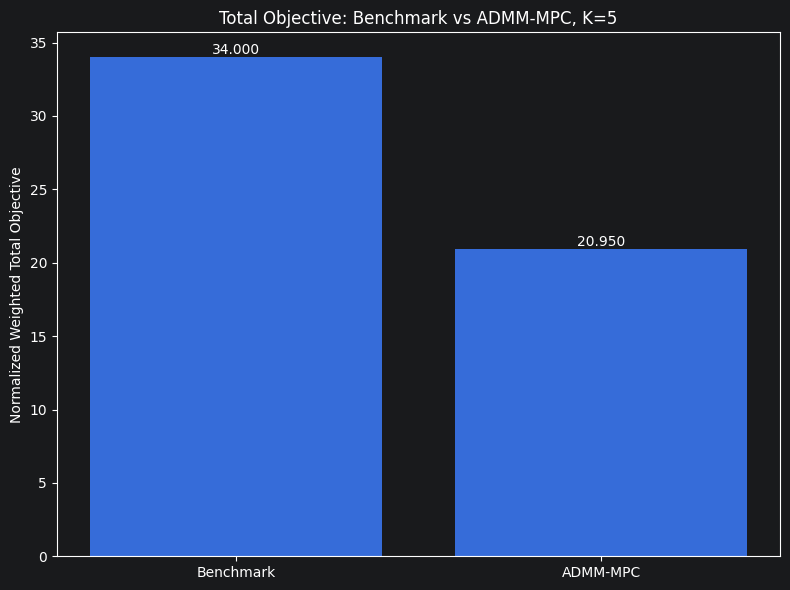

Benchmark terms:
Mainline Delay: 72848.691
Local Delay: 15225.654
Fairness Penalty: 25.453
Doorway Penalty: 5712.108
Safe Threshold Penalty: 1410495.372
Physical Capacity Penalty: 0.0
Spillback Penalty: 3454.202
Total Capacity Penalty: 1419661.681
Raw Objective: 1507761.479

ADMM-MPC terms:
Mainline Delay: 44529.476
Local Delay: 15916.4
Fairness Penalty: 3.307
Doorway Penalty: 1088.34
Safe Threshold Penalty: 522358.525
Physical Capacity Penalty: 0.0
Spillback Penalty: 7330.142
Total Capacity Penalty: 530777.007
Raw Objective: 591226.19

Normalized weighted total objective:
Benchmark = 34.0
ADMM-MPC = 20.949832
Difference = -13.050168
Percent change = -38.383 %

ADMM-MPC iteration statistics:
Average ADMM iterations = 21.383
Maximum ADMM iterations = 115
Minimum ADMM iterations = 20
Total MPC horizon availability violations: 0
PASS: all MPC horizons satisfy cumulative ramp-vehicle availability.
 Ramp Queue Saturation Diagnostic 

u1 | final queue = 28.669 | max queue = 28.669 | final/ma

In [1]:
%run Benchmark_calculation.ipynb
%run ADMM_MPC.ipynb

In [2]:
# Fixed scaled observed-release ablation
fixed_scale = 0.9

# Fixed scaled observed-release policy:
# each timestep releases a fixed fraction of the observed PeMS release.
# This is not feedback-based and does not optimize, but it still follows
# the observed time-varying release profile.
fixed_release_series = {
    ramp: [
        fixed_scale * float(value)
        for value in observed_release_series[ramp]
    ]
    for ramp in observed_release_series
}

fixed_history = simulate_state_based_benchmark_120_steps(
    num_steps=num_steps,
    mainline_initial_state=mainline_initial_state,
    ramp_queue_0=ramp_queue_0,
    q_in_boundary_series=q_in_boundary_series,
    observed_release_series=fixed_release_series,
    ramp_arrival_series=ramp_arrival_series,
    f_out_series=f_out_series,
    doorway_capacity=doorway_capacity,
    physical_capacity=physical_capacity,
    safe_threshold_capacity=safe_threshold_capacity,
    ramp_name_map=ramp_name_map,
    ramp_max_queue_named=ramp_max_queue_named,
    ramp_max_queue_by_u=ramp_max_queue_by_u,
    tt_ff_min=tt_ff_min,
    delta_t=delta_t,
    gamma=gamma,
    lambda_1=lambda_1,
    lambda_2=lambda_2,
    lambda_3=lambda_3,
    lambda_4=lambda_4,
)

fixed_totals = compute_totals_from_history(fixed_history)
fixed_objective = compute_normalized_objective_from_totals(fixed_totals)

baseline_totals = official_totals
baseline_objective = compute_normalized_objective_from_totals(baseline_totals)

mpc_totals = compute_totals_from_history(admm_mpc_history_120)
mpc_objective = compute_normalized_objective_from_totals(mpc_totals)

baseline_system_delay = (
    baseline_totals["mainline_delay"]
    + baseline_totals["local_delay"]
)

fixed_system_delay = (
    fixed_totals["mainline_delay"]
    + fixed_totals["local_delay"]
)

mpc_system_delay = (
    mpc_totals["mainline_delay"]
    + mpc_totals["local_delay"]
)

print(f"Fixed scaled observed-release policy ({fixed_scale} x observed release):")
print(f"  Mainline delay: {fixed_totals['mainline_delay']:.1f} veh-min")
print(f"  Local delay:    {fixed_totals['local_delay']:.1f} veh-min")
print(f"  Total system:   {fixed_system_delay:.1f} veh-min")
print(f"  Fairness:       {fixed_totals['fairness_penalty']:.2f}")
print(f"  Doorway:        {fixed_totals['doorway_penalty']:.1f}")
print(f"  Safe penalty:   {fixed_totals['safe_penalty']:.1f}")
print(f"  Spillback:      {fixed_totals['spillback_penalty']:.2f}")
print(f"  Normalized obj: {fixed_objective:.3f}")

print("\nThree-way comparison (total system delay):")
print(f"  Baseline observed release:          {baseline_system_delay:.1f} veh-min")
print(f"  Fixed {fixed_scale} x observed:     {fixed_system_delay:.1f} veh-min")
print(f"  ADMM-MPC:                           {mpc_system_delay:.1f} veh-min")

print("\nThree-way comparison (normalized weighted objective):")
print(f"  Baseline observed release:          {baseline_objective:.3f}")
print(f"  Fixed {fixed_scale} x observed:     {fixed_objective:.3f}")
print(f"  ADMM-MPC:                           {mpc_objective:.3f}")

Fixed scaled observed-release policy (0.9 x observed release):
  Mainline delay: 60496.5 veh-min
  Local delay:    15458.9 veh-min
  Total system:   75955.4 veh-min
  Fairness:       21.69
  Doorway:        4450.1
  Safe penalty:   905688.0
  Spillback:      5088.15
  Normalized obj: 28.617

Three-way comparison (total system delay):
  Baseline observed release:          88074.3 veh-min
  Fixed 0.9 x observed:     75955.4 veh-min
  ADMM-MPC:                           60445.9 veh-min

Three-way comparison (normalized weighted objective):
  Baseline observed release:          34.000
  Fixed 0.9 x observed:     28.617
  ADMM-MPC:                           20.950


A fixed scaled observed-release policy was added as an ablation to test whether the ADMM-MPC improvement is simply caused by reducing ramp releases. This policy releases 90% of the observed PeMS ramp discharge at every timestep, while preserving the same time-varying release profile and the same exogenous ramp arrivals.

The fixed policy improves over the field-observed release baseline, reducing total system delay from 88,074.3 veh-min to 75,955.4 veh-min. However, ADMM-MPC further reduces total system delay to 60,445.9 veh-min. This shows that ADMM-MPC is not merely reproducing a simple lower-release policy; its rolling-horizon optimization provides additional benefit beyond uniform scaled metering.

In [3]:
# Fixed Scaled-Release Ablation Grid

import pandas as pd

arrival_multipliers_to_test = [1.0, 1.1, 1.25, 1.5]
fixed_release_scales_to_test = [0.7, 0.8, 0.9, 1.0]

ablation_rows = []

# NEW: store every fixed-policy history so later diagnostics can use the exact case
fixed_policy_histories = {}


def build_scaled_release_series(observed_release_series, fixed_scale):
    return {
        ramp: [
            fixed_scale * float(value)
            for value in observed_release_series[ramp]
        ]
        for ramp in observed_release_series
    }


def build_arrival_series_from_multiplier(observed_release_series, arrival_multiplier):
    return {
        ramp: [
            arrival_multiplier * float(value)
            for value in observed_release_series[ramp]
        ]
        for ramp in observed_release_series
    }


for arrival_multiplier_test in arrival_multipliers_to_test:

    ramp_arrival_series_test = build_arrival_series_from_multiplier(
        observed_release_series,
        arrival_multiplier_test
    )

    for fixed_scale in fixed_release_scales_to_test:

        fixed_release_series = build_scaled_release_series(
            observed_release_series,
            fixed_scale
        )

        fixed_history = simulate_state_based_benchmark_120_steps(
            num_steps=num_steps,
            mainline_initial_state=mainline_initial_state,
            ramp_queue_0=ramp_queue_0,
            q_in_boundary_series=q_in_boundary_series,
            observed_release_series=fixed_release_series,
            ramp_arrival_series=ramp_arrival_series_test,
            f_out_series=f_out_series,
            doorway_capacity=doorway_capacity,
            physical_capacity=physical_capacity,
            safe_threshold_capacity=safe_threshold_capacity,
            ramp_name_map=ramp_name_map,
            ramp_max_queue_named=ramp_max_queue_named,
            ramp_max_queue_by_u=ramp_max_queue_by_u,
            tt_ff_min=tt_ff_min,
            delta_t=delta_t,
            gamma=gamma,
            lambda_1=lambda_1,
            lambda_2=lambda_2,
            lambda_3=lambda_3,
            lambda_4=lambda_4,
        )

        # NEW: save this exact history by arrival multiplier and release scale
        fixed_policy_histories[(arrival_multiplier_test, fixed_scale)] = fixed_history

        fixed_totals = compute_totals_from_history(fixed_history)

        fixed_system_delay = (
            fixed_totals["mainline_delay"]
            + fixed_totals["local_delay"]
        )

        fixed_normalized_objective = compute_normalized_objective_from_totals(
            fixed_totals
        )

        ablation_rows.append({
            "arrival_multiplier": arrival_multiplier_test,
            "release_scale": fixed_scale,
            "mainline_delay": fixed_totals["mainline_delay"],
            "local_delay": fixed_totals["local_delay"],
            "total_system_delay": fixed_system_delay,
            "fairness_penalty": fixed_totals["fairness_penalty"],
            "doorway_penalty": fixed_totals["doorway_penalty"],
            "safe_penalty": fixed_totals["safe_penalty"],
            "physical_penalty": fixed_totals["physical_penalty"],
            "spillback_penalty": fixed_totals["spillback_penalty"],
            "capacity_penalty": fixed_totals["capacity_penalty"],
            "raw_objective": fixed_totals["raw_objective"],
            "normalized_objective": fixed_normalized_objective,
        })


fixed_policy_ablation_df = pd.DataFrame(ablation_rows)

print("Fixed scaled-release ablation grid")
display(
    fixed_policy_ablation_df.round({
        "mainline_delay": 1,
        "local_delay": 1,
        "total_system_delay": 1,
        "fairness_penalty": 3,
        "doorway_penalty": 1,
        "safe_penalty": 1,
        "physical_penalty": 1,
        "spillback_penalty": 3,
        "capacity_penalty": 1,
        "raw_objective": 1,
        "normalized_objective": 3,
    })
)

Fixed scaled-release ablation grid


,arrival_multiplier,release_scale,mainline_delay,local_delay,total_system_delay,fairness_penalty,doorway_penalty,safe_penalty,physical_penalty,spillback_penalty,capacity_penalty,raw_objective,normalized_objective
0,1.00,0.7,35905.6,14272.0,50177.6,41.522,2484.9,2708.8,0.0,1131.507,6325.1,56544.2,17.955
1,1.00,0.8,48243.2,13086.9,61330.1,63.519,3388.2,459165.0,0.0,440.186,462993.5,524387.1,24.042
2,1.00,0.9,60496.5,9785.3,70281.8,127.320,4450.1,905688.0,0.0,63.635,910201.8,980610.8,31.667
3,1.00,1.0,72848.7,0.0,72848.7,0.000,5712.1,1410495.4,0.0,0.000,1416207.5,1489056.2,31.500
4,1.10,0.7,35905.6,14874.8,50780.4,31.209,2484.9,2708.8,0.0,2140.311,7333.9,58145.5,17.735
5,1.10,0.8,48243.2,14272.0,62515.2,41.522,3388.2,459165.0,0.0,1131.507,463684.8,526241.5,23.356
6,1.10,0.9,60496.5,13086.9,73583.4,63.519,4450.1,905688.0,0.0,440.186,910578.3,984225.2,29.432
7,1.10,1.0,72848.7,9785.3,82634.0,127.320,5712.1,1410495.4,0.0,63.635,1416271.1,1499032.4,37.154
8,1.25,0.7,35905.6,15352.8,51258.4,23.476,2484.9,2708.8,0.0,4232.522,9426.2,60708.0,17.766
9,1.25,0.8,48243.2,15070.3,63313.5,28.016,3388.2,459165.0,0.0,2757.801,465311.1,528652.5,23.113


In [4]:
# Compare each fixed policy against the release_scale = 1.0 baseline
# under the same arrival multiplier.
summary_rows = []

for arrival_multiplier_test in arrival_multipliers_to_test:

    sub_df = fixed_policy_ablation_df[
        fixed_policy_ablation_df["arrival_multiplier"]
        == arrival_multiplier_test
    ]

    baseline_row = sub_df[sub_df["release_scale"] == 1.0].iloc[0]

    baseline_delay = baseline_row["total_system_delay"]
    baseline_objective = baseline_row["normalized_objective"]

    for _, row in sub_df.iterrows():

        delay_change_pct = (
            100
            * (row["total_system_delay"] - baseline_delay)
            / baseline_delay
        )

        objective_change_pct = (
            100
            * (row["normalized_objective"] - baseline_objective)
            / baseline_objective
        )

        summary_rows.append({
            "arrival_multiplier": arrival_multiplier_test,
            "release_scale": row["release_scale"],
            "total_system_delay": row["total_system_delay"],
            "delay_change_vs_scale_1_pct": delay_change_pct,
            "normalized_objective": row["normalized_objective"],
            "objective_change_vs_scale_1_pct": objective_change_pct,
            "spillback_penalty": row["spillback_penalty"],
            "local_delay": row["local_delay"],
        })


fixed_policy_summary_df = pd.DataFrame(summary_rows)

print("Fixed scaled-release ablation summary")
display(
    fixed_policy_summary_df.round({
        "total_system_delay": 1,
        "delay_change_vs_scale_1_pct": 3,
        "normalized_objective": 3,
        "objective_change_vs_scale_1_pct": 3,
        "spillback_penalty": 3,
        "local_delay": 1,
    })
)

Fixed scaled-release ablation summary


,arrival_multiplier,release_scale,total_system_delay,delay_change_vs_scale_1_pct,normalized_objective,objective_change_vs_scale_1_pct,spillback_penalty,local_delay
0,1.00,0.7,50177.6,-31.121,17.955,-43.001,1131.507,14272.0
1,1.00,0.8,61330.1,-15.812,24.042,-23.677,440.186,13086.9
2,1.00,0.9,70281.8,-3.524,31.667,0.531,63.635,9785.3
3,1.00,1.0,72848.7,0.000,31.500,0.000,0.000,0.0
4,1.10,0.7,50780.4,-38.548,17.735,-52.266,2140.311,14874.8
5,1.10,0.8,62515.2,-24.347,23.356,-37.139,1131.507,14272.0
6,1.10,0.9,73583.4,-10.953,29.432,-20.784,440.186,13086.9
7,1.10,1.0,82634.0,0.000,37.154,0.000,63.635,9785.3
8,1.25,0.7,51258.4,-40.843,17.766,-48.491,4232.522,15352.8
9,1.25,0.8,63313.5,-26.930,23.113,-32.988,2757.801,15070.3


In [5]:
# Official-setting comparison:
# Fixed scaled-release policies vs ADMM-MPC at arrival_multiplier = 1.5


official_arrival_multiplier = 1.5

official_fixed_df = fixed_policy_ablation_df[
    fixed_policy_ablation_df["arrival_multiplier"]
    == official_arrival_multiplier
].copy()

mpc_totals = compute_totals_from_history(admm_mpc_history_120)

mpc_system_delay = (
    mpc_totals["mainline_delay"]
    + mpc_totals["local_delay"]
)

mpc_normalized_objective = compute_normalized_objective_from_totals(
    mpc_totals
)

comparison_rows = []

for _, row in official_fixed_df.iterrows():
    comparison_rows.append({
        "policy": f"Fixed {row['release_scale']} x observed",
        "arrival_multiplier": official_arrival_multiplier,
        "mainline_delay": row["mainline_delay"],
        "local_delay": row["local_delay"],
        "total_system_delay": row["total_system_delay"],
        "safe_penalty": row["safe_penalty"],
        "spillback_penalty": row["spillback_penalty"],
        "normalized_objective": row["normalized_objective"],
    })

comparison_rows.append({
    "policy": "ADMM-MPC",
    "arrival_multiplier": official_arrival_multiplier,
    "mainline_delay": mpc_totals["mainline_delay"],
    "local_delay": mpc_totals["local_delay"],
    "total_system_delay": mpc_system_delay,
    "safe_penalty": mpc_totals["safe_penalty"],
    "spillback_penalty": mpc_totals["spillback_penalty"],
    "normalized_objective": mpc_normalized_objective,
})

official_policy_comparison_df = pd.DataFrame(comparison_rows)

print("Arrival-multiplier comparison")
display(
    official_policy_comparison_df.round({
        "mainline_delay": 1,
        "local_delay": 1,
        "total_system_delay": 1,
        "safe_penalty": 1,
        "spillback_penalty": 3,
        "normalized_objective": 3,
    })
)

Arrival-multiplier comparison


,policy,arrival_multiplier,mainline_delay,local_delay,total_system_delay,safe_penalty,spillback_penalty,normalized_objective
0,Fixed 0.7 x observed,1.5,35905.6,15751.5,51657.1,2708.8,9300.842,18.277
1,Fixed 0.8 x observed,1.5,48243.2,15626.3,63869.5,459165.0,7039.258,23.418
2,Fixed 0.9 x observed,1.5,60496.5,15458.9,75955.4,905688.0,5088.150,28.617
3,Fixed 1.0 x observed,1.5,72848.7,15225.7,88074.3,1410495.4,3454.202,34.000
4,ADMM-MPC,1.5,44529.5,15916.4,60445.9,522358.5,7330.142,20.950


In [6]:
# Served-vehicles / demand-accounting check across policies

ramp_ids = ["u1", "u2", "u3", "u4", "u5"]

# Use official arrival-multiplier setting
official_arrival_multiplier = 1.5

# Pull exact fixed-policy histories from the saved grid histories
fixed_07_history = fixed_policy_histories[(official_arrival_multiplier, 0.7)]
fixed_08_history = fixed_policy_histories[(official_arrival_multiplier, 0.8)]
fixed_09_history = fixed_policy_histories[(official_arrival_multiplier, 0.9)]
fixed_10_history = fixed_policy_histories[(official_arrival_multiplier, 1.0)]

# Exogenous demand under official arrival multiplier
total_ramp_demand = sum(
    float(ramp_arrival_series[ramp][t])
    for ramp in ramp_ids
    for t in range(num_steps)
)

total_initial_ramp_queue = sum(
    float(ramp_queue_0[ramp])
    for ramp in ramp_ids
)

total_available_ramp_demand = (
    total_initial_ramp_queue
    + total_ramp_demand
)

total_boundary_in = sum(
    float(q_in_boundary_series[t])
    for t in range(num_steps)
)


def ramp_accounting(history, release_key):
    released = sum(
        float(history[release_key][t][ramp])
        for ramp in ramp_ids
        for t in range(num_steps)
    )

    spilled = sum(
        float(history["spillback"][t][ramp])
        for ramp in ramp_ids
        for t in range(num_steps)
    )

    queued_end = sum(
        float(history["R"][-1][ramp])
        for ramp in ramp_ids
    )

    downstream_throughput = sum(
        float(history["q_out"][t]["Cell 8"])
        for t in range(num_steps)
    )

    residual = (
        total_available_ramp_demand
        - released
        - queued_end
        - spilled
    )

    return released, spilled, queued_end, downstream_throughput, residual


policies = [
    ("Baseline", state_based_benchmark_history, "observed_release"),
    ("Fixed 0.7x", fixed_07_history, "observed_release"),
    ("Fixed 0.8x", fixed_08_history, "observed_release"),
    ("Fixed 0.9x", fixed_09_history, "observed_release"),
    ("Fixed 1.0x", fixed_10_history, "observed_release"),
    ("ADMM-MPC", admm_mpc_history_120, "u_apply"),
]

print(
    "Official arrival multiplier:",
    official_arrival_multiplier
)

print(
    "Total ramp demand arrivals:",
    round(total_ramp_demand, 3),
    "veh"
)

print(
    "Initial ramp queue:",
    round(total_initial_ramp_queue, 3),
    "veh"
)

print(
    "Total available ramp demand:",
    round(total_available_ramp_demand, 3),
    "veh"
)

print(
    "Mainline boundary inflow:",
    round(total_boundary_in, 3),
    "veh\n"
)

header = (
    f"{'policy':14s}"
    f"{'released':>10s}"
    f"{'queued':>10s}"
    f"{'spilled':>10s}"
    f"{'served%':>10s}"
    f"{'spill%':>10s}"
    f"{'ML exit':>10s}"
    f"{'resid':>10s}"
)

print(header)


for name, history, release_key in policies:
    released, spilled, queued_end, throughput, residual = ramp_accounting(
        history,
        release_key
    )

    served_pct = 100 * released / total_available_ramp_demand
    spill_pct = 100 * spilled / total_available_ramp_demand

    print(
        f"{name:14s}"
        f"{released:10.1f}"
        f"{queued_end:10.1f}"
        f"{spilled:10.1f}"
        f"{served_pct:9.1f}%"
        f"{spill_pct:9.1f}%"
        f"{throughput:10.1f}"
        f"{residual:10.3f}"
    )

print("\nHow to read this:")
print("  released = ramp vehicles allowed onto the freeway")
print("  queued   = ramp vehicles still waiting at the final timestep")
print("  spilled  = vehicles exceeding ramp storage capacity")
print("  served%  = released / total available ramp demand")
print("  spill%   = spilled / total available ramp demand")
print("  ML exit  = vehicles discharged from Cell 8")
print("  resid    = initial queue + arrivals - released - queued - spilled")
print("\nA near-zero residual means ramp demand is accounted for.")
print("If ADMM-MPC has much higher spillback than baseline, part of its delay reduction")
print("comes from shifting congestion pressure to ramps rather than simply serving more vehicles.")

Official arrival multiplier: 1.5
Total ramp demand arrivals: 6300.0 veh
Initial ramp queue: 0.0 veh
Total available ramp demand: 6300.0 veh
Mainline boundary inflow: 8353.0 veh

policy          released    queued   spilled   served%    spill%   ML exit     resid
Baseline          4200.0     278.5    1821.5     66.7%     28.9%   10119.2     0.000
Fixed 0.7x        2940.0     278.5    3081.5     46.7%     48.9%   10119.2     0.000
Fixed 0.8x        3360.0     278.5    2661.5     53.3%     42.2%   10119.2     0.000
Fixed 0.9x        3780.0     278.5    2241.5     60.0%     35.6%   10119.2     0.000
Fixed 1.0x        4200.0     278.5    1821.5     66.7%     28.9%   10119.2     0.000
ADMM-MPC          3290.6     278.5    2730.9     52.2%     43.3%   10119.2     0.000

How to read this:
  released = ramp vehicles allowed onto the freeway
  queued   = ramp vehicles still waiting at the final timestep
  spilled  = vehicles exceeding ramp storage capacity
  served%  = released / total available